In [1]:
import pandas as pd

df = pd.read_csv('USD_UZS_data.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)


In [2]:
df['close_lag1'] = df['close'].shift(1)
df['close_lag7'] = df['close'].shift(7)
df['close_ma7'] = df['close'].rolling(7).mean().shift(1)
df['change_lag1'] = df['change'].shift(1)



print(df.tail(10))

           date      open      high       low     close  change  close_lag1  \
4302 2026-01-22  12087.02  12170.48  12069.74  12139.89    0.35    12107.56   
4303 2026-01-23  12137.03  12164.27  12048.94  12058.27   -0.64    12139.89   
4304 2026-01-26  12059.12  12110.03  12044.17  12082.32    0.20    12058.27   
4305 2026-01-27  12109.30  12152.06  12083.82  12128.52    0.25    12082.32   
4306 2026-01-28  12134.34  12185.92  12100.37  12121.16   -0.12    12128.52   
4307 2026-01-29  12138.54  12182.39  12109.24  12117.81   -0.25    12121.16   
4308 2026-01-30  12144.77  12279.48  12102.40  12219.17    0.62    12117.81   
4309 2026-02-02  12262.45  12298.87  12211.71  12231.53    0.10    12219.17   
4310 2026-02-03  12244.58  12270.93  12234.04  12266.68    0.24    12231.53   
4311 2026-02-04  12249.08  12278.45  12240.70  12264.84    0.04    12266.68   

      close_lag7     close_ma7  change_lag1  
4302    12081.44  12028.492857         0.64  
4303    12006.98  12036.842857        

In [3]:
df['target'] = df['close'].shift(-4)
df = df.dropna()

df = df.reset_index(drop=True)


df = df[df['date'] >= '2017-09-18']

df.tail()

,date,open,high,low,close,change,close_lag1,close_lag7,close_ma7,change_lag1,target
4296,2026-01-23,12137.03,12164.27,12048.94,12058.27,-0.64,12139.89,12006.98,12036.842857,0.35,12117.81
4297,2026-01-26,12059.12,12110.03,12044.17,12082.32,0.20,12058.27,11973.29,12044.170000,-0.64,12219.17
4298,2026-01-27,12109.30,12152.06,12083.82,12128.52,0.25,12082.32,11963.85,12059.745714,0.20,12231.53
4299,2026-01-28,12134.34,12185.92,12100.37,12121.16,-0.12,12128.52,12024.37,12083.270000,0.25,12266.68
4300,2026-01-29,12138.54,12182.39,12109.24,12117.81,-0.25,12121.16,12041.96,12097.097143,-0.12,12264.84


In [4]:
from sklearn.model_selection import train_test_split

features = ['close_lag1', 'close_lag7', 'close_ma7', 'change_lag1']

X = df[features]
y = df['target']

In [5]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [6]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    max_depth=10,
    learning_rate = 0.05,
    random_state=42,
    subsample=0.8,
    colsample_bytree = 0.8
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [7]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
mae_model = mean_absolute_error(y_test, y_pred)

print("Model MAE:", mae_model)

Model MAE: 145.60614508672586


In [8]:
y_naive = X_test['close_lag1']
mae_naive = mean_absolute_error(y_test, y_naive)

print("Naive MAE:", mae_naive)

Naive MAE: 59.75543577981649


In [9]:
import joblib
joblib.dump(model, 'usduzs.pkl')

['usduzs.pkl']

In [10]:
model = joblib.load('usduzs.pkl')
X_test.tail()

,close_lag1,close_lag7,close_ma7,change_lag1
4296,12139.89,12006.98,12036.842857,0.35
4297,12058.27,11973.29,12044.170000,-0.64
4298,12082.32,11963.85,12059.745714,0.20
4299,12128.52,12024.37,12083.270000,0.25
4300,12121.16,12041.96,12097.097143,-0.12


In [11]:
my_date = pd.DataFrame([{
    'close_lag1': 12139.89,
    'close_lag7': 12006.98,
    'close_ma7': 12036.842857,
    'change_lag1': 0.23
}])

predict_close = model.predict(my_date)



In [12]:
def add_new_row(df, predicted_close):
    df = df.copy()
    new_date = df['date'].iloc[-1] + pd.Timedelta(days=1)
    last_close = df['close'].iloc[-1]
    new_change = predicted_close - last_close
    new_row = {
        'date': new_date,
        'close': predicted_close,
        'change': new_change,
        'close_lag1': last_close,
        'close_lag7': df['close'].iloc[-7],
        'close_ma7': df['close'].iloc[-7:].mean(),
        'change_lag1': df['change'].iloc[-1]
    }
    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)




In [13]:
def predict_by_day(df, model, days=60):
    for i in range(days):

        my_date = pd.DataFrame([{
            'close_lag1': df['close'].iloc[-1],
            'close_lag7': df['close'].iloc[-7],
            'close_ma7': df['close'].iloc[-7:].mean(),
            'change_lag1': df['change'].iloc[-1]
        }])

        predicted_close = model.predict(my_date)[0]
        print(f"{i+1}-kundagi bashorat: {predicted_close:.2f}")
        df = add_new_row(df, predicted_close)

    df.to_csv('test.csv', index=False)

predict_by_day(df, model, days=7)

1-kundagi bashorat: 12163.85
2-kundagi bashorat: 12079.32
3-kundagi bashorat: 12175.25
4-kundagi bashorat: 12085.13
5-kundagi bashorat: 12174.65
6-kundagi bashorat: 12091.59
7-kundagi bashorat: 12174.65


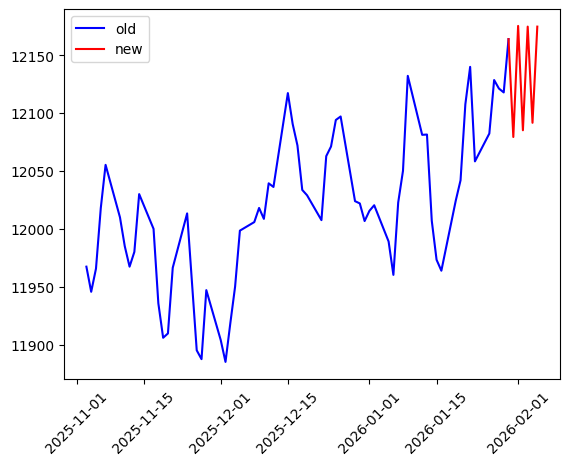

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('test.csv')

# если date строка — лучше сразу в datetime
df['date'] = pd.to_datetime(df['date'])

data = df[df['date'] >= '2026-01-30']
old_data = df[(df['date'] > '2025-11-01') & (df['date'] <= '2026-01-30')]

plt.plot(old_data['date'], old_data['close'], color='blue', label='old')
plt.plot(data['date'], data['close'], color='red', label='new')
plt.xticks(rotation=45)
plt.legend()
plt.show()